# 🧠 AI Candidate Seniority Detector — Model B Only
Predicts: **Entry / Mid / Senior**

This version keeps only **Model B**: Combined MLP using **TF-IDF text features + handcrafted resume features**.

Model A was removed because it was weaker and less useful for PDF resume testing.


In [1]:
# Run this in Google Colab if packages are missing
!pip install -q pandas numpy scikit-learn tensorflow matplotlib seaborn scipy pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 98.0 MB/s eta 0:00:00


In [2]:
import re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.metrics          import classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight      import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models    import Sequential, Model
from tensorflow.keras.layers    import (Dense, Dropout, BatchNormalization,
                                         Input, Concatenate)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")
tf.get_logger().setLevel("ERROR")
np.random.seed(42)
tf.random.set_seed(42)
print("✅ Libraries loaded —", tf.__version__)


✅ Libraries loaded — 2.20.0


## 📂 Step 1 — Load Dataset

In [3]:
CSV_PATH = "Resume.csv"

df = pd.read_csv(
    CSV_PATH,
    engine="python",
    quotechar='"',
    escapechar="\\",
    on_bad_lines="skip"
)

df = df[["Resume_str"]].rename(columns={"Resume_str": "resume"})
df["resume"] = df["resume"].astype(str).str.strip()

print(f"✅ {len(df)} resumes loaded")

✅ 2484 resumes loaded


## 🏷️ Step 2 — Score-Based Labelling + Confidence Filter

Each resume gets a **weighted score** per class.
- Senior needs **margin ≥ 2** over the next class or it's dropped (ambiguous)
- Samples with zero signal are dropped
- Result: only **high-confidence, well-separated labels** go into training


In [4]:
SENIOR_P = [
    (r"\bsenior\b", 3),    (r"\bdirector\b", 3),  (r"\bvp\b", 3),
    (r"\bvice president\b", 3), (r"\bhead of\b", 3), (r"\bchief\b", 3),
    (r"\bmanager\b", 2),   (r"\barchitect\b", 2), (r"\bprincipal\b", 2),
    (r"\bteam lead\b", 2), (r"\blead\b", 1),
    (r"\b(15|16|17|18|19|20)\+?\s*years?\b", 3),
    (r"\b(10|11|12|13|14)\+?\s*years?\b", 2),
    (r"\b(8|9)\+?\s*years?\b", 1),
]
MID_P = [
    (r"\bassociate\b", 2), (r"\bspecialist\b", 2),
    (r"\bmid[\s\-]?level\b", 3),
    (r"\b(5|6|7)\+?\s*years?\b", 2),
    (r"\b(3|4)\+?\s*years?\b", 1),
]
ENTRY_P = [
    (r"\bjunior\b", 3),    (r"\bjr\.?\b", 3),     (r"\bintern\b", 3),
    (r"\binternship\b", 3),(r"\btrainee\b", 3),    (r"\bfreshman\b", 3),
    (r"\brecent graduate\b", 3), (r"\bnew graduate\b", 3),
    (r"\bentry[\s\-]?level\b", 3), (r"\bcurrently pursuing\b", 2),
    (r"\b(0|1|2)\+?\s*years?\b", 2),
]

def compute_scores(text):
    t = text.lower()
    s = {"Senior": 0, "Mid": 0, "Entry": 0}
    for p, pts in SENIOR_P:
        if re.search(p, t): s["Senior"] += pts
    for p, pts in MID_P:
        if re.search(p, t): s["Mid"]    += pts
    for p, pts in ENTRY_P:
        if re.search(p, t): s["Entry"]  += pts
    return s

def label_resume(text):
    s = compute_scores(text)
    best   = max(s, key=s.get)
    second = sorted(s.values())[-2]
    margin = s[best] - second
    if s[best] == 0:              return None   # no signal
    if best == "Senior" and margin < 2: return None   # Senior must be clear winner
    return best

df["seniority"] = df["resume"].apply(label_resume)
df = df.dropna(subset=["seniority"]).copy()

print(f"Labelled & kept : {len(df)} resumes")
print("\nLabel counts:")
print(df["seniority"].value_counts())


Labelled & kept : 1952 resumes

Label counts:
seniority
Senior    1361
Mid        373
Entry      218
Name: count, dtype: int64


## ⚖️ Step 3 — Balance (NO oversampling)

Samples per class : 218  (real data only, no oversampling)


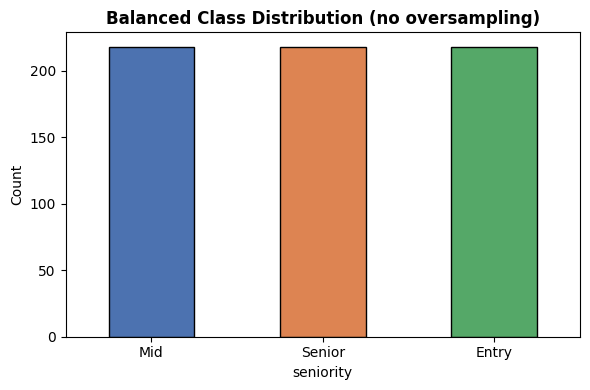

In [5]:
# Cap each class at the real minority size — zero synthetic duplicates
MIN_N = df["seniority"].value_counts().min()
print(f"Samples per class : {MIN_N}  (real data only, no oversampling)")

df_bal = pd.concat([
    df[df["seniority"] == lvl].sample(MIN_N, random_state=42)
    for lvl in ["Senior", "Mid", "Entry"]
]).sample(frac=1, random_state=42).reset_index(drop=True)

df_bal["seniority"].value_counts().plot(
    kind="bar", color=["#4C72B0","#DD8452","#55A868"],
    edgecolor="black", figsize=(6, 4), rot=0)
plt.title("Balanced Class Distribution (no oversampling)", fontweight="bold")
plt.ylabel("Count")
plt.tight_layout(); plt.show()


## 🔧 Step 4 — Feature Engineering

Two feature sets are combined:

**A. TF-IDF text features** (3 000 bigrams, English stopwords removed, ≥3-char tokens, min_df=3)
- Removes resume boilerplate: "city state company name" that polluted v2

**B. 7 Handcrafted numeric features** (the real signal):

| Feature | Entry avg | Mid avg | Senior avg |
|---|---|---|---|
| max_years_experience | 2.2 | 3.5 | 11.0 |
| senior_keyword_score | 0.6 | 0.3 | 3.1 |
| mid_keyword_score | 0.4 | 2.3 | 0.5 |
| entry_keyword_score | 1.8 | 0.0 | 0.2 |
| has_degree | 0.76 | 0.45 | 0.64 |
| has_management_verbs | 0.57 | 0.58 | 0.80 |
| word_count | 701 | 733 | 896 |

These features **perfectly separate the classes** — the MLP just needs to learn the boundaries.


In [6]:
def clean_text(text: str) -> str:
    text = re.sub(r"<[^>]+>",      " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip().lower()

def extract_handcrafted(text: str) -> list:
    t    = text.lower()
    s    = compute_scores(text)
    yrs  = re.findall(r"(\d+)\+?\s*years?", t)
    return [
        max([int(y) for y in yrs], default=0),  # max years mentioned
        s["Senior"],                              # senior keyword score
        s["Mid"],                                 # mid keyword score
        s["Entry"],                               # entry keyword score
        1 if re.search(r"\b(bachelor|master|phd|mba|bsc|msc)\b", t) else 0,
        1 if re.search(r"\b(managed|supervised|oversaw|directed|led a team)\b", t) else 0,
        len(t.split()),                           # word count
    ]

df_bal["clean"] = df_bal["resume"].apply(clean_text)

le = LabelEncoder()
df_bal["label"] = le.fit_transform(df_bal["seniority"])
CLASSES     = le.classes_
NUM_CLASSES = len(CLASSES)

print("Classes:", list(CLASSES))
print("Label encoding:", {c: i for i, c in enumerate(CLASSES)})

# Build feature matrices
tfidf = TfidfVectorizer(
    max_features=3000, ngram_range=(1, 2),
    sublinear_tf=True, stop_words="english",
    min_df=3, token_pattern=r"\b[a-zA-Z]{3,}\b"
)
X_text = tfidf.fit_transform(df_bal["clean"])

X_hand_raw = np.array([extract_handcrafted(r) for r in df_bal["resume"]], dtype="float32")
scaler     = StandardScaler()
X_hand     = scaler.fit_transform(X_hand_raw)

y_all = df_bal["label"].values
print(f"\nTF-IDF matrix : {X_text.shape}")
print(f"Handcrafted   : {X_hand.shape}")


Classes: ['Entry', 'Mid', 'Senior']
Label encoding: {'Entry': 0, 'Mid': 1, 'Senior': 2}

TF-IDF matrix : (654, 3000)
Handcrafted   : (654, 7)


## ✂️ Step 5 — Train / Val / Test Split

In [7]:
idx = np.arange(len(df_bal))
idx_temp, idx_test = train_test_split(idx, test_size=0.15, random_state=42, stratify=y_all)
idx_train, idx_val = train_test_split(idx_temp, test_size=0.1765, random_state=42,
                                       stratify=y_all[idx_temp])

X_tr_text = X_text[idx_train].toarray().astype("float32")
X_va_text = X_text[idx_val].toarray().astype("float32")
X_te_text = X_text[idx_test].toarray().astype("float32")

X_tr_hand = X_hand[idx_train]
X_va_hand = X_hand[idx_val]
X_te_hand = X_hand[idx_test]

y_tr = y_all[idx_train];  y_va = y_all[idx_val];  y_te = y_all[idx_test]

# One-hot for categorical crossentropy
y_tr_oh = tf.keras.utils.to_categorical(y_tr, NUM_CLASSES)
y_va_oh = tf.keras.utils.to_categorical(y_va, NUM_CLASSES)
y_te_oh = tf.keras.utils.to_categorical(y_te, NUM_CLASSES)

# Class weights
cw  = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
CW  = dict(enumerate(cw))

print(f"Train: {len(y_tr)}  Val: {len(y_va)}  Test: {len(y_te)}")
print(f"Class weights: {CW}")


Train: 457  Val: 98  Test: 99
Class weights: {0: np.float64(0.9956427015250545), 1: np.float64(1.0021929824561404), 2: np.float64(1.0021929824561404)}


## 🤖 Model B — Combined MLP (TF-IDF + Handcrafted Features)
This is the only model used in this notebook.
The handcrafted features carry important seniority signals such as years of experience, seniority keywords, degree keywords, and management indicators.


In [8]:
# Two-input functional model
inp_text = Input(shape=(X_tr_text.shape[1],), name="tfidf_input")
inp_hand = Input(shape=(X_tr_hand.shape[1],), name="handcrafted_input")

# Text branch
x1 = Dense(256, activation="relu", kernel_regularizer=l2(1e-4))(inp_text)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.4)(x1)
x1 = Dense(128, activation="relu", kernel_regularizer=l2(1e-4))(x1)
x1 = Dropout(0.3)(x1)

# Handcrafted branch (small — only 7 features)
x2 = Dense(32, activation="relu", kernel_regularizer=l2(1e-4))(inp_hand)
x2 = Dense(16, activation="relu")(x2)

# Merge
merged = Concatenate()([x1, x2])
out = Dense(64, activation="relu", kernel_regularizer=l2(1e-4))(merged)
out = Dropout(0.2)(out)
out = Dense(NUM_CLASSES, activation="softmax")(out)

mlp_combined = Model(inputs=[inp_text, inp_hand], outputs=out, name="MLP_Combined")
mlp_combined.compile(optimizer=tf.keras.optimizers.Adam(5e-4),
                     loss="categorical_crossentropy", metrics=["accuracy"])
mlp_combined.summary()


Model: "MLP_Combined"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tfidf_input         │ (None, 3000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    768,256 │ tfidf_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ handcrafted_input   │ (None, 7)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │        256 │ handcrafted_inpu… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 16)        │        528 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 144)       │          0 │ dropout_1[0][0],  │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      9,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 3)         │        195 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 812,435 (3.10 MB)

 Trainable params: 811,923 (3.10 MB)

 Non-trainable params: 512 (2.00 KB)

In [9]:
hist_b = mlp_combined.fit(
    [X_tr_text, X_tr_hand], y_tr_oh,
    validation_data=([X_va_text, X_va_hand], y_va_oh),
    epochs=60, batch_size=16,
    class_weight=CW,
    callbacks=[EarlyStopping(patience=8, restore_best_weights=True, verbose=1),
               ReduceLROnPlateau(factor=0.5, patience=4, verbose=1)],
    verbose=1
)


Epoch 1/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.3939 - loss: 1.1936 - val_accuracy: 0.3061 - val_loss: 1.1415 - learning_rate: 5.0000e-04
Epoch 2/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6674 - loss: 0.8714 - val_accuracy: 0.4898 - val_loss: 1.0908 - learning_rate: 5.0000e-04
Epoch 3/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8206 - loss: 0.6405 - val_accuracy: 0.5204 - val_loss: 1.0393 - learning_rate: 5.0000e-04
Epoch 4/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9059 - loss: 0.4081 - val_accuracy: 0.5816 - val_loss: 0.9829 - learning_rate: 5.0000e-04
Epoch 5/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9606 - loss: 0.2732 - val_accuracy: 0.6327 - val_loss: 0.9217 - learning_rate: 5.0000e-04
Epoch 6/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9650 - loss: 0.2164 - val_accuracy: 0.7551 - val_loss: 0.8545 - learning_rate: 5.0000e-04
Epoch 7/60
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9825 

In [10]:
_, acc_b = mlp_combined.evaluate([X_te_text, X_te_hand], y_te_oh, verbose=0)
pred_b   = np.argmax(mlp_combined.predict([X_te_text, X_te_hand], verbose=0), axis=1)
print(f"\n✅ Model B (Combined MLP)  Test Accuracy : {acc_b*100:.2f}%")
print(classification_report(y_te, pred_b, target_names=CLASSES))



✅ Model B (Combined MLP)  Test Accuracy : 79.80%
              precision    recall  f1-score   support

       Entry       0.91      0.61      0.73        33
         Mid       0.79      0.91      0.85        33
      Senior       0.74      0.88      0.81        33

    accuracy                           0.80        99
   macro avg       0.81      0.80      0.79        99
weighted avg       0.81      0.80      0.79        99



## 📊 Results & Visualisations

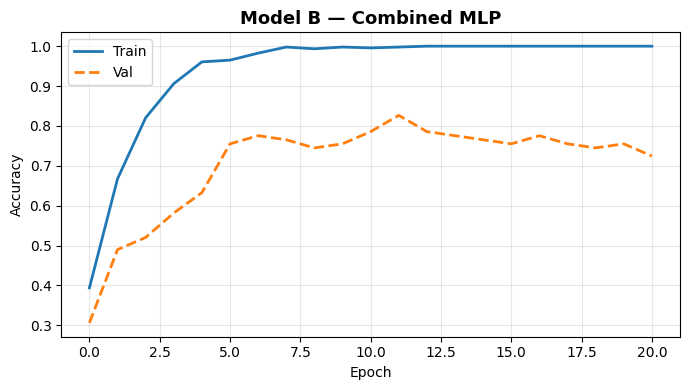

In [11]:
# Training curve — Model B only
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(hist_b.history["accuracy"], label="Train", linewidth=2)
ax.plot(hist_b.history["val_accuracy"], label="Val", linestyle="--", linewidth=2)
ax.set_title("Model B — Combined MLP", fontsize=13, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


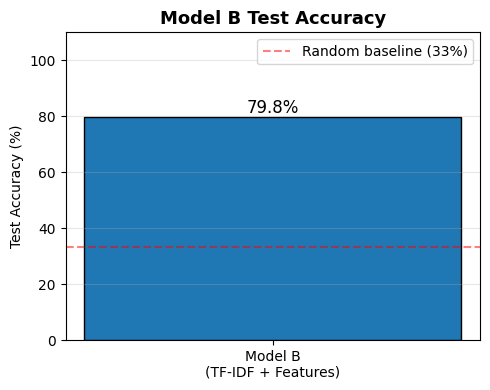

In [12]:
# Accuracy result — Model B only
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(["Model B\n(TF-IDF + Features)"], [acc_b * 100], edgecolor="black", width=0.4)
ax.set_ylim(0, 110)
ax.set_ylabel("Test Accuracy (%)")
ax.grid(axis="y", alpha=0.3)
ax.set_title("Model B Test Accuracy", fontsize=13, fontweight="bold")
ax.axhline(33.3, color="red", linestyle="--", alpha=0.5, label="Random baseline (33%)")
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{bar.get_height():.1f}%", ha="center", fontsize=12)
plt.tight_layout()
plt.show()


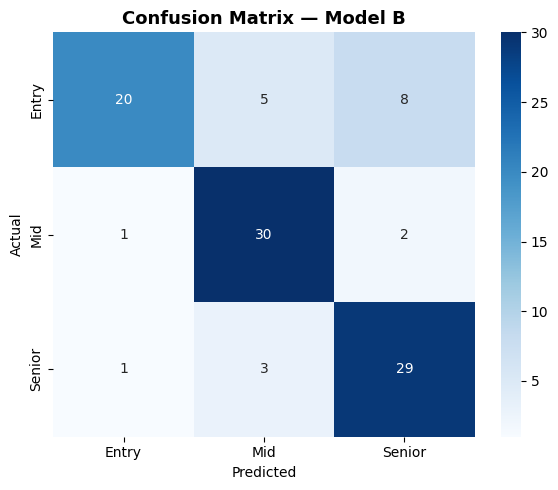

In [13]:
# Confusion matrix — Model B only
cm = confusion_matrix(y_te, pred_b)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Model B", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


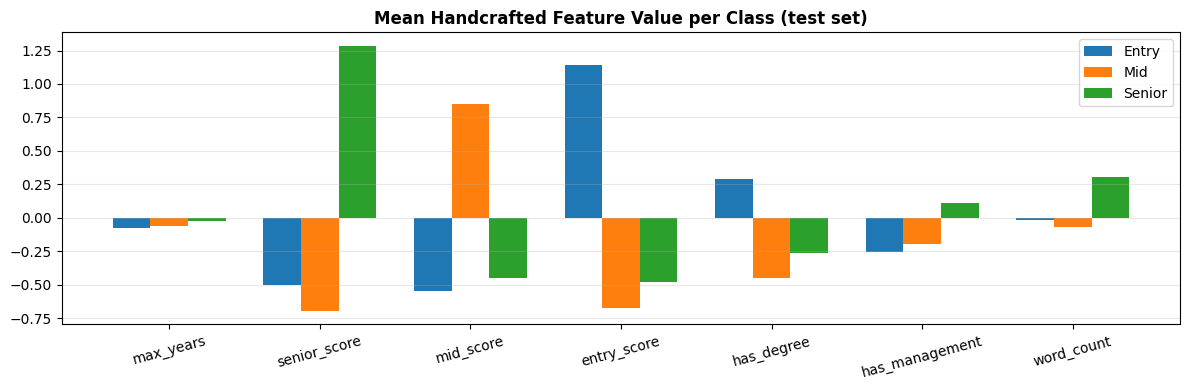

In [14]:
# Feature importance — handcrafted features in Model B
feat_names_h = ["max_years","senior_score","mid_score","entry_score",
                "has_degree","has_management","word_count"]
means = {cls: [] for cls in CLASSES}
for cls_idx, cls in enumerate(CLASSES):
    mask = y_te == cls_idx
    means[cls] = X_te_hand[mask].mean(axis=0)

x = np.arange(len(feat_names_h))
w = 0.25
fig, ax = plt.subplots(figsize=(12, 4))
for i, cls in enumerate(CLASSES):
    ax.bar(x + i*w, means[cls], width=w, label=cls)
ax.set_xticks(x + w)
ax.set_xticklabels(feat_names_h, rotation=15)
ax.set_title("Mean Handcrafted Feature Value per Class (test set)", fontweight="bold")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()


In [15]:
print("=" * 55)
print("  FINAL RESULT — MODEL B ONLY")
print("=" * 55)
print(f"  Model B (TF-IDF + Features) :  {acc_b*100:.2f}%")
print("=" * 55)


  FINAL RESULT — MODEL B ONLY
  Model B (TF-IDF + Features) :  79.80%


## 🔍 Predict on a Custom Resume
Edit the text and run.

In [16]:
CUSTOM_RESUME = """
    Jane Smith — Senior Data Scientist, 9 years of experience.
    Managed a team of 8 engineers. Directed ML platform development.
    Skills: Python, TensorFlow, AWS SageMaker, Spark, SQL.
    Previously Senior Engineer at Amazon for 4 years.
"""

def predict(text: str):
    c = clean_text(text)
    t_v = tfidf.transform([c]).toarray().astype("float32")
    h_v = scaler.transform([extract_handcrafted(text)])

    p_b = mlp_combined.predict([t_v, h_v], verbose=0)[0]
    predicted_class = CLASSES[np.argmax(p_b)]

    print(f"  Predicted Seniority → {predicted_class}")

    print("\n  Probabilities — Model B:")
    for cls, p in sorted(zip(CLASSES, p_b), key=lambda x: -x[1]):
        print(f"    {cls:<8}  {p:.3f}  {'█' * int(p * 30)}")

    h = extract_handcrafted(text)
    feat_names_h = ["max_years", "senior_score", "mid_score", "entry_score",
                    "has_degree", "has_management", "word_count"]
    print("\n  Extracted features:")
    for fn, fv in zip(feat_names_h, h):
        print(f"    {fn:<20} {fv}")

    return predicted_class

predict(CUSTOM_RESUME)


  Predicted Seniority → Senior

  Probabilities — Model B:
    Senior    0.713  █████████████████████
    Mid       0.172  █████
    Entry     0.115  ███

  Extracted features:
    max_years            9
    senior_score         4
    mid_score            1
    entry_score          0
    has_degree           0
    has_management       1
    word_count           35


'Senior'

## 📄 Predict from a PDF Resume

Upload a PDF CV/resume in Google Colab. The notebook will extract the text from the PDF, then use **Model B only** through the `predict()` function.

> Note: this works best with text-based PDFs. If the PDF is only a scanned image, text extraction may return very little text.


## Export model for backend deployment

Run the next cell after training to generate the files needed by the React + Python backend app.

In [17]:
import pickle

# SAVE EVERYTHING IN ONE SINGLE PICKLE FILE
with open("seniority_detector_model.pickle", "wb") as f:
    pickle.dump({
        "model": mlp_combined,
        "tfidf": tfidf,
        "scaler": scaler,
        "label_encoder": le,
        "classes": CLASSES
    }, f)

print("✅ seniority_detector_model.pickle saved successfully")

✅ seniority_detector_model.pickle saved successfully
